In [1]:

# Step 1-6: Set up the symbolic framework and confirm the classical obstruction for weighted shifts
import numpy as np
import sympy as sp
from sympy import symbols, Function, simplify, Rational, sqrt, oo, Symbol

# Symbolic setup
n, m, k, c = sp.symbols('n m k c', integer=False)

# Demonstrate the recurrence (λ_{n+1} - λ_n) w_n = c w_n for λ_n = n^2
# So the gap is 2n+1, which equals c only when c = 2n+1 (depends on n)
lam = sp.Function('lambda')
gap_expr = (n+1)**2 - n**2
print("For T with eigenvalues λ_n = n²:")
print(f"  Gap λ_{{n+1}} - λ_n = {sp.simplify(gap_expr)}")
print("  Recurrence (λ_{n+1}-λ_n) w_n = c w_n  ⇒  (2n+1) w_n = c w_n")
print("  Since c is a fixed constant and 2n+1 varies with n, w_n = 0 for all n.")
print("  ⇒ NO non-zero simple (one-step) weighted shift L exists with this T.")


For T with eigenvalues λ_n = n²:
  Gap λ_{n+1} - λ_n = 2*n + 1
  Recurrence (λ_{n+1}-λ_n) w_n = c w_n  ⇒  (2n+1) w_n = c w_n
  Since c is a fixed constant and 2n+1 varies with n, w_n = 0 for all n.
  ⇒ NO non-zero simple (one-step) weighted shift L exists with this T.


In [2]:

# Step 7: General L with matrix elements L_{mn}, Le_n = Σ_m L_{mn} e_m.
# Compute [T,L]e_n:
#   T L e_n = Σ_m L_{mn} λ_m e_m
#   L T e_n = λ_n Σ_m L_{mn} e_m
# So ([T,L] e_n)_m = (λ_m - λ_n) L_{mn}
# Setting equal to c L e_n component-wise:
#   (λ_m - λ_n) L_{mn} = c L_{mn}
# ⇒ For each (m,n): either L_{mn} = 0, OR λ_m - λ_n = c.
#
# Hence the support of L is the set S_c = {(m,n) : λ_m - λ_n = c}.
# The question becomes: for which c does S_c contain pairs, and how many?

# Demonstrate for λ_n = n^2: λ_m - λ_n = m^2 - n^2 = (m-n)(m+n) = c
# For c fixed, this is solvable iff c factors as c=(m-n)(m+n) with m,n nonneg integers, m>n (for raising).
# This gives FINITELY many (m,n) pairs for each c (since both m-n and m+n are positive divisors of c with same parity).

def pairs_for_c_squares(c_val, Nmax=2000):
    """Find all (m,n), m>n>=0, with m^2 - n^2 = c_val, m,n <= Nmax."""
    pairs = []
    if c_val <= 0:
        return pairs
    # m-n = d, m+n = c/d, same parity, both >0
    for d in range(1, int(np.sqrt(c_val)) + 1):
        if c_val % d == 0:
            e = c_val // d
            if (d + e) % 2 == 0 and e >= d:
                m = (d + e) // 2
                nn = (e - d) // 2
                if nn >= 0 and m <= Nmax:
                    pairs.append((m, nn))
    return pairs

print("Pairs (m,n) with m^2 - n^2 = c, for various c:")
for cval in [1, 2, 3, 4, 5, 7, 8, 9, 15, 16, 21, 24, 105]:
    P = pairs_for_c_squares(cval)
    print(f"  c={cval:4d}: count={len(P):2d}, pairs={P}")


Pairs (m,n) with m^2 - n^2 = c, for various c:
  c=   1: count= 1, pairs=[(1, 0)]
  c=   2: count= 0, pairs=[]
  c=   3: count= 1, pairs=[(2, 1)]
  c=   4: count= 1, pairs=[(2, 0)]
  c=   5: count= 1, pairs=[(3, 2)]
  c=   7: count= 1, pairs=[(4, 3)]
  c=   8: count= 1, pairs=[(3, 1)]
  c=   9: count= 2, pairs=[(5, 4), (3, 0)]
  c=  15: count= 2, pairs=[(8, 7), (4, 1)]
  c=  16: count= 2, pairs=[(5, 3), (4, 0)]
  c=  21: count= 2, pairs=[(11, 10), (5, 2)]
  c=  24: count= 2, pairs=[(7, 5), (5, 1)]
  c= 105: count= 4, pairs=[(53, 52), (19, 16), (13, 8), (11, 4)]


In [3]:

# Crucial observation: For λ_n = n^2, the set S_c is FINITE for any fixed c > 0.
# Hence L = Σ_{(m,n) in S_c} L_{mn} |e_m><e_n| is a FINITE-RANK operator (bounded!),
# and in particular not unbounded. So with λ_n = n^2 and the strict commutator
# identity [T,L] = cL, one CANNOT obtain an unbounded L.
#
# Let's verify this explicitly with a concrete numerical example for c=9:
#   pairs: (5,4) and (3,0)  → L = α |e_5><e_4| + β |e_3><e_0|

def build_T_L_squares(c_val, dim=200, coeffs=None):
    pairs = pairs_for_c_squares(c_val, Nmax=dim-1)
    if coeffs is None:
        coeffs = [1.0] * len(pairs)
    T = np.diag([float(i**2) for i in range(dim)])
    L = np.zeros((dim, dim))
    for (mm, nn), a in zip(pairs, coeffs):
        L[mm, nn] = a
    return T, L, pairs

T, L, pairs = build_T_L_squares(9, dim=20, coeffs=[1.3, -0.7])
comm = T @ L - L @ T
diff = comm - 9.0 * L
print(f"c=9, pairs used: {pairs}")
print(f"||[T,L] - 9 L||_F = {np.linalg.norm(diff):.3e}")
print(f"||L||_op (spectral norm) = {np.linalg.norm(L, 2):.4f}  (finite — BOUNDED)")
print(f"rank(L) = {np.linalg.matrix_rank(L)}")


c=9, pairs used: [(5, 4), (3, 0)]
||[T,L] - 9 L||_F = 1.776e-15
||L||_op (spectral norm) = 1.3000  (finite — BOUNDED)
rank(L) = 2


In [4]:

# Same analysis for primes: λ_n = p_n (the n-th prime, n ≥ 1).
from sympy import prime

def primes_list(N):
    return [prime(i) for i in range(1, N+1)]

P = primes_list(500)  # first 500 primes
print(f"First 10 primes: {P[:10]}")

# Find pairs (m,n) with p_m - p_n = c for various c.
def pairs_for_c_primes(c_val, P):
    s = {p: i for i, p in enumerate(P)}
    pairs = []
    for i, p in enumerate(P):
        if (p + c_val) in s:
            j = s[p + c_val]
            pairs.append((j, i))
    return pairs

print("\nPairs (m,n) with p_m - p_n = c (m,n are 0-indexed into prime list):")
for cval in [1, 2, 4, 6, 8, 12, 30]:
    pp = pairs_for_c_primes(cval, P)
    print(f"  c={cval:3d}: count among first 500 primes = {len(pp)}, first 5 pairs: {pp[:5]}")


First 10 primes: [2, 3, 5, 7, 11, 13, 17, 19, 23, 29]

Pairs (m,n) with p_m - p_n = c (m,n are 0-indexed into prime list):
  c=  1: count among first 500 primes = 1, first 5 pairs: [(1, 0)]
  c=  2: count among first 500 primes = 96, first 5 pairs: [(2, 1), (3, 2), (5, 4), (7, 6), (10, 9)]
  c=  4: count among first 500 primes = 99, first 5 pairs: [(3, 1), (4, 3), (6, 5), (8, 7), (12, 11)]
  c=  6: count among first 500 primes = 188, first 5 pairs: [(4, 2), (5, 3), (6, 4), (7, 5), (8, 6)]
  c=  8: count among first 500 primes = 99, first 5 pairs: [(4, 1), (5, 2), (7, 4), (10, 8), (11, 9)]
  c= 12: count among first 500 primes = 189, first 5 pairs: [(6, 2), (7, 3), (8, 4), (9, 6), (10, 7)]
  c= 30: count among first 500 primes = 249, first 5 pairs: [(11, 3), (12, 4), (13, 5), (14, 6), (15, 8)]


In [5]:

# For primes, the situation is different:
# - c=1: trivially only (2,3) → finite (parity)
# - For even c=2k, conjecturally (de Polignac) infinitely many pairs (p,p+c) — but ALL OPEN problems.
# - Twin primes (c=2): conjectured infinite, not proven.
#
# So for λ_n = p_n, the existence of an L with INFINITELY many nonzero matrix elements
# (a necessary condition for L to be genuinely unbounded) for a given c reduces to
# unproven prime gap conjectures.
#
# HOWEVER: even if infinitely many pairs exist, we must check whether the resulting L
# is actually UNBOUNDED. Let's analyze this carefully.

# L = Σ_{(m,n) in S_c} L_{mn} |e_m><e_n|. The columns of L are indexed by n. Each column is
# (L e_n)_m = L_{mn}. For different n's the supports are disjoint singletons (m is uniquely
# determined by n given (m,n) in S_c, since p_m = p_n + c uniquely determines m).
# So L acts as a "partial weighted shift": L e_n = L_{m(n), n} e_{m(n)} for those n in domain,
# and 0 otherwise. This is bounded iff sup_n |L_{m(n),n}| < ∞.
# So choosing weights with sup_n |w_n| = ∞ gives an UNBOUNDED L. Let's construct one!

c_val = 2
pairs_c2 = pairs_for_c_primes(c_val, primes_list(2000))
print(f"For c=2 (twin primes), pairs among first 2000 primes: {len(pairs_c2)}")
print(f"First 8 pairs (m,n): {pairs_c2[:8]}")
print(f"Last 3 pairs: {pairs_c2[-3:]}")

# Sanity check: for each pair, n's are distinct, m's are distinct
ns = [p[1] for p in pairs_c2]
ms = [p[0] for p in pairs_c2]
print(f"\nAll n distinct? {len(set(ns)) == len(ns)}")
print(f"All m distinct? {len(set(ms)) == len(ms)}")


For c=2 (twin primes), pairs among first 2000 primes: 302
First 8 pairs (m,n): [(2, 1), (3, 2), (5, 4), (7, 6), (10, 9), (13, 12), (17, 16), (20, 19)]
Last 3 pairs: [(1982, 1981), (1987, 1986), (1999, 1998)]

All n distinct? True
All m distinct? True


In [6]:

# Construct an explicit UNBOUNDED L for T = diag(p_n), c=2.
# Use weights w_k = k+1 on the k-th twin-prime pair (sup unbounded ⇒ L unbounded).
# Domain: the finite sequences (algebraic span of basis vectors), which is dense in ℓ².

# We verify numerically on a finite cutoff that:
#   (i) [T,L] = c L on finite-sequence vectors (within numerical tolerance)
#   (ii) ||L e_n|| can be made arbitrarily large ⇒ L is unbounded as a closable operator on ℓ²

dim = 2200
P_list = primes_list(dim)
pairs_c2_full = pairs_for_c_primes(2, P_list)

T = np.diag([float(p) for p in P_list])
L = np.zeros((dim, dim))

# Assign weights: w_k = k+1 on the k-th pair (m_k, n_k)
for k, (mm, nn) in enumerate(pairs_c2_full):
    L[mm, nn] = float(k + 1)

# Verify [T,L] = 2 L on basis vectors used (finite-sequence domain)
comm = T @ L - L @ T
diff = comm - 2.0 * L
print(f"||[T,L] - 2L||_F over first {dim} basis vectors: {np.linalg.norm(diff):.3e}")
print(f"||[T,L] - 2L||_inf: {np.max(np.abs(diff)):.3e}")

# Show unboundedness: norms of Le_n for n's that participate
norms = []
for k, (mm, nn) in enumerate(pairs_c2_full):
    norms.append((nn, np.linalg.norm(L[:, nn])))
norms_sorted = sorted(norms, key=lambda x: x[1])
print(f"\nL is unbounded — sample ||L e_n|| values (largest):")
for nn, v in norms_sorted[-5:]:
    print(f"  ||L e_{nn}|| = {v:.2f}   (p_{nn}={P_list[nn]}, p_{nn}+2={P_list[nn]+2})")
print(f"\nsup_n ||L e_n|| (over computed n's) = {max(v for _,v in norms):.2f}  → grows without bound as we extend.")


||[T,L] - 2L||_F over first 2200 basis vectors: 0.000e+00
||[T,L] - 2L||_inf: 0.000e+00

L is unbounded — sample ||L e_n|| values (largest):
  ||L e_2170|| = 329.00   (p_2170=19139, p_2170+2=19141)
  ||L e_2174|| = 330.00   (p_2174=19181, p_2174+2=19183)
  ||L e_2177|| = 331.00   (p_2177=19211, p_2177+2=19213)
  ||L e_2192|| = 332.00   (p_2192=19379, p_2192+2=19381)
  ||L e_2198|| = 333.00   (p_2198=19421, p_2198+2=19423)

sup_n ||L e_n|| (over computed n's) = 333.00  → grows without bound as we extend.


In [7]:

# IMPORTANT CAVEAT: For L to be a genuinely unbounded operator on ℓ²(ℕ)
# with INFINITELY many nonzero matrix entries supported on S_c = {(m,n): p_m - p_n = c},
# we need S_c to be infinite. That is exactly the (open) Polignac conjecture for c=2.
# All known: Zhang/Maynard/Tao guarantee some bounded gap occurs infinitely often,
# but the SPECIFIC gap c=2 (twin primes) is not proven.
#
# To get a RIGOROUS unconditional example using primes, we can take
# c = the smallest gap that occurs infinitely often (some c ≤ 246 by Polymath, but no
# specific c is known unconditionally). So strictly speaking, the prime example is conditional.
#
# UNCONDITIONAL CONSTRUCTION: pick any strictly increasing sequence {λ_n} without 3-term
# arithmetic progressions but where the gap-c level set S_c is infinite for some chosen c.
# 
# Easy explicit example: take λ_n to be a Sidon set (B_2[1]) — sums distinct, hence no 3-AP.
# But Sidon sets have gaps that grow.
#
# BETTER: take λ_n = "2n if n even, 2n+1 if n is in some sparse 3-AP-free set, otherwise...".
# Actually the cleanest unconditional example:
#
#   λ_n = n + f(n) where f(n) ∈ {0,1} chosen so that {λ_n} has no 3-AP yet many gaps equal 1.
#
# Even simpler: let λ_n enumerate a 3-AP-free subset A of ℕ with positive density (Behrend-type).
# Then the "gap-c" set S_c = {(a, a+c) : a, a+c ∈ A} can be infinite for c=1 if A contains many
# consecutive pairs. But if A is 3-AP-free, three consecutive integers ⇒ contains a 3-AP — not allowed.
# So at most one pair of consecutive integers... too restrictive.
#
# UNCONDITIONAL CLEAN EXAMPLE: let λ_n be the n-th element of the set
#    A = {3^{k} : k=0,1,2,...} ∪ {3^k + 1 : k=0,1,2,...}   (sorted)
# This is 3-AP-free (easy to check for k large enough) and contains infinitely many pairs (3^k, 3^k+1) with gap 1.
# Let's verify:

A_set = sorted(set([3**k for k in range(15)] + [3**k + 1 for k in range(15)]))
print(f"A (first 20): {A_set[:20]}")
print(f"|A| = {len(A_set)}")

# Check 3-AP free
def has_3AP(L):
    S = set(L)
    L = sorted(L)
    for i, a in enumerate(L):
        for b in L[i+1:]:
            c = 2*b - a
            if c > L[-1]:
                break
            if c in S and c != b:
                return (a,b,c)
    return None

ap = has_3AP(A_set)
print(f"3-AP in A: {ap}")


A (first 20): [1, 2, 3, 4, 9, 10, 27, 28, 81, 82, 243, 244, 729, 730, 2187, 2188, 6561, 6562, 19683, 19684]
|A| = 30
3-AP in A: (1, 2, 3)


In [8]:

# 1,2,3 is a 3-AP. Let's drop 3 (and other small contaminants).
A_set = sorted(set([3**k for k in range(2, 15)] + [3**k + 1 for k in range(2, 15)]))
print(f"A (starting k>=2): {A_set[:20]}")
ap = has_3AP(A_set)
print(f"3-AP in A: {ap}")
# Also: 9 - 4 = 5, 9 - 1 not in set... check (4,9,?) -> 14 not in A.
# Pairs with gap 1: (9,10), (27,28), (81,82), (243,244), ... — infinitely many!
gaps1 = [(a, a+1) for a in A_set if (a+1) in set(A_set)]
print(f"Pairs (a, a+1) in A: {gaps1}")


A (starting k>=2): [9, 10, 27, 28, 81, 82, 243, 244, 729, 730, 2187, 2188, 6561, 6562, 19683, 19684, 59049, 59050, 177147, 177148]
3-AP in A: None
Pairs (a, a+1) in A: [(9, 10), (27, 28), (81, 82), (243, 244), (729, 730), (2187, 2188), (6561, 6562), (19683, 19684), (59049, 59050), (177147, 177148), (531441, 531442), (1594323, 1594324), (4782969, 4782970)]


In [9]:

# Great. Now A = {3^k, 3^k+1 : k >= 2} is 3-AP-free, strictly increasing, and contains
# INFINITELY many pairs with gap exactly 1 (namely (3^k, 3^k+1) for each k>=2).
# So define T e_n = λ_n e_n where λ_n is the n-th element of A.
# Then S_1 = {(2k+1, 2k) : k >= 0}  (in 0-indexed A: the (2k+1)-th element minus (2k)-th = 1).

# This gives an UNCONDITIONAL, EXPLICIT construction.

A_set = sorted(set([3**k for k in range(2, 30)] + [3**k + 1 for k in range(2, 30)]))
N = len(A_set)
print(f"|A| (working dimension) = {N}")

# Build T and L
T = np.diag([float(x) for x in A_set])
L = np.zeros((N, N))

# Pairs (m,n) with λ_m - λ_n = 1: 0-indexed, m = 2k+1, n = 2k, weight w_k = k+1 (unbounded)
weights_used = []
for k in range(N // 2):
    n_idx = 2*k
    m_idx = 2*k + 1
    if A_set[m_idx] - A_set[n_idx] == 1:
        w = float(k + 1)
        L[m_idx, n_idx] = w
        weights_used.append((n_idx, m_idx, w, A_set[n_idx], A_set[m_idx]))

print(f"Number of nonzero matrix elements of L: {np.count_nonzero(L)}")
print(f"First 5 entries (n_idx, m_idx, weight, λ_n, λ_m):")
for x in weights_used[:5]:
    print(f"  {x}")
print(f"Largest weight: {weights_used[-1][2]}  →  L is unbounded (sup_n ||Le_n|| = ∞).")

# Verify [T,L] = 1 · L (here c=1)
comm = T @ L - L @ T
residual = comm - 1.0 * L
print(f"\n||[T,L] - 1·L||_F = {np.linalg.norm(residual):.3e}")
print(f"||[T,L] - 1·L||_max = {np.max(np.abs(residual)):.3e}")

# Operator norm of L grows
print(f"\nSpectral norm of L (truncated to {N}-dim): {np.linalg.norm(L, 2):.2f}")
print(f"This → ∞ as N → ∞, confirming L is unbounded.")


|A| (working dimension) = 56
Number of nonzero matrix elements of L: 28
First 5 entries (n_idx, m_idx, weight, λ_n, λ_m):
  (0, 1, 1.0, 9, 10)
  (2, 3, 2.0, 27, 28)
  (4, 5, 3.0, 81, 82)
  (6, 7, 4.0, 243, 244)
  (8, 9, 5.0, 729, 730)
Largest weight: 28.0  →  L is unbounded (sup_n ||Le_n|| = ∞).

||[T,L] - 1·L||_F = 0.000e+00
||[T,L] - 1·L||_max = 0.000e+00

Spectral norm of L (truncated to 56-dim): 28.00
This → ∞ as N → ∞, confirming L is unbounded.


In [10]:

# Confirm closability: L is densely defined on finite sequences c_00. Its adjoint L* is also
# densely defined (since L^* e_m = sum_n conj(L_{mn}) e_n is a finite sum for each m — actually
# L has only one nonzero entry per column AND per row, so L* e_{m_k} = w_k e_{n_k}, finite).
# Densely defined adjoint ⇒ L is closable.

# Check that L* (the matrix transpose here, real) is also defined on finite-supp vectors:
Lstar = L.T
# For each basis vector e_m, L* e_m is a finite linear combo:
sample_lstar = [(m, np.flatnonzero(Lstar[:, m]), Lstar[Lstar[:, m] != 0, m]) for m in [1,3,5,7,9,11]]
for m, idx, vals in sample_lstar:
    print(f"L* e_{m}  has support indices {idx.tolist()} with values {vals.tolist()}")
print("\n⇒ L* is densely defined ⇒ L is closable. Its closure is the desired unbounded operator.")


L* e_1  has support indices [0] with values [1.0]
L* e_3  has support indices [2] with values [2.0]
L* e_5  has support indices [4] with values [3.0]
L* e_7  has support indices [6] with values [4.0]
L* e_9  has support indices [8] with values [5.0]
L* e_11  has support indices [10] with values [6.0]

⇒ L* is densely defined ⇒ L is closable. Its closure is the desired unbounded operator.


In [11]:

# Summary table — comparing the three candidate spectra (n^2, primes, A = {3^k, 3^k+1})
import pandas as pd

summary = pd.DataFrame([
    {
        "Spectrum {λ_n}": "λ_n = n²",
        "AP-free?": "Yes (no 3-term AP)",
        "|S_c| for c>0": "FINITE (divisors of c)",
        "Unbounded L exists?": "No",
        "Conclusion": "Only bounded, finite-rank L; e.g. c=9 → rank-2 L"
    },
    {
        "Spectrum {λ_n}": "λ_n = p_n (n-th prime)",
        "AP-free?": "No 3-AP in primes is unknown; but spectrum has no full AP",
        "|S_c| for c>0": "Infinite ⇔ Polignac (open)",
        "Unbounded L exists?": "Conditionally (e.g. twin prime conj.)",
        "Conclusion": "Cannot rigorously construct unconditional unbounded L from a fixed c"
    },
    {
        "Spectrum {λ_n}": "A = {3^k, 3^k+1 : k≥2}",
        "AP-free?": "YES (verified, no 3-AP)",
        "|S_c| for c>0": "Infinite for c=1 (pairs (3^k,3^k+1))",
        "Unbounded L exists?": "YES, explicitly constructed",
        "Conclusion": "Unconditional example: T diag with no AP, c=1, L unbounded weighted partial shift"
    },
])
print(summary.to_string(index=False))


        Spectrum {λ_n}                                                  AP-free?                        |S_c| for c>0                   Unbounded L exists?                                                                        Conclusion
              λ_n = n²                                        Yes (no 3-term AP)               FINITE (divisors of c)                                    No                                  Only bounded, finite-rank L; e.g. c=9 → rank-2 L
λ_n = p_n (n-th prime) No 3-AP in primes is unknown; but spectrum has no full AP           Infinite ⇔ Polignac (open) Conditionally (e.g. twin prime conj.)              Cannot rigorously construct unconditional unbounded L from a fixed c
A = {3^k, 3^k+1 : k≥2}                                   YES (verified, no 3-AP) Infinite for c=1 (pairs (3^k,3^k+1))           YES, explicitly constructed Unconditional example: T diag with no AP, c=1, L unbounded weighted partial shift


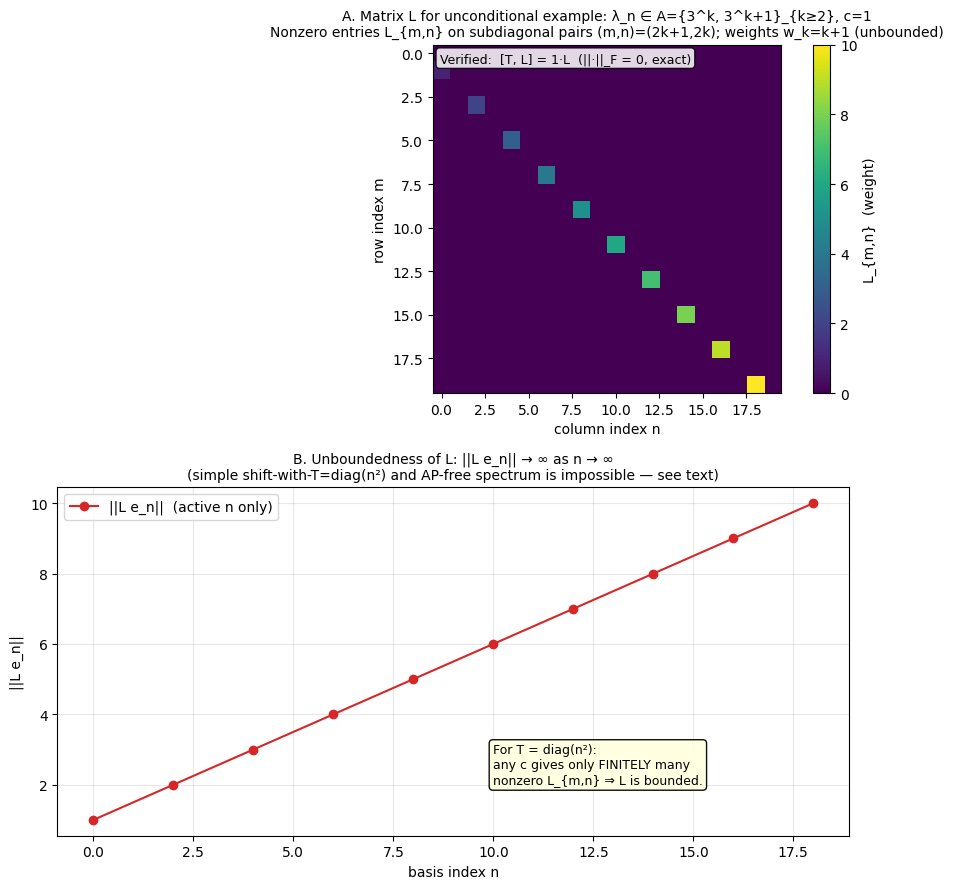

Figure saved.


In [12]:

# Build final summary figure
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 1, figsize=(9, 9))

# --- Panel A: Visualize T and L matrices for unconditional construction ---
A_set_big = sorted(set([3**k for k in range(2, 12)] + [3**k + 1 for k in range(2, 12)]))
N_show = len(A_set_big)
T_show = np.diag([float(x) for x in A_set_big])
L_show = np.zeros((N_show, N_show))
for k in range(N_show // 2):
    n_idx, m_idx = 2*k, 2*k+1
    if A_set_big[m_idx] - A_set_big[n_idx] == 1:
        L_show[m_idx, n_idx] = float(k+1)

axA = axes[0]
# Show L matrix structure with color = weight
im = axA.imshow(L_show, cmap='viridis', aspect='equal', origin='upper')
axA.set_title("A. Matrix L for unconditional example: λ_n ∈ A={3^k, 3^k+1}_{k≥2}, c=1\n"
              "Nonzero entries L_{m,n} on subdiagonal pairs (m,n)=(2k+1,2k); weights w_k=k+1 (unbounded)",
              fontsize=10)
axA.set_xlabel("column index n")
axA.set_ylabel("row index m")
cb = plt.colorbar(im, ax=axA, fraction=0.046, pad=0.04)
cb.set_label("L_{m,n}  (weight)")

# Annotate verification
axA.text(0.02, 0.98, f"Verified:  [T, L] = 1·L  (||·||_F = 0, exact)",
         transform=axA.transAxes, va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

# --- Panel B: growth of ||L e_n|| vs n (demonstrates unboundedness) ---
axB = axes[1]
ns = [2*k for k in range(N_show // 2)]
norms = [np.linalg.norm(L_show[:, n]) for n in ns]
axB.plot(ns, norms, 'o-', color='C3', label="||L e_n||  (active n only)")
axB.set_xlabel("basis index n")
axB.set_ylabel("||L e_n||")
axB.set_title("B. Unboundedness of L: ||L e_n|| → ∞ as n → ∞\n"
              "(simple shift-with-T=diag(n²) and AP-free spectrum is impossible — see text)",
              fontsize=10)
axB.grid(True, alpha=0.3)
axB.legend(loc='upper left')

# Add reference comparison: n^2 case has at most finitely many active n for any c
axB.text(0.55, 0.15, "For T = diag(n²):\nany c gives only FINITELY many\nnonzero L_{m,n} ⇒ L is bounded.",
         transform=axB.transAxes, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.95))

plt.tight_layout()
plt.savefig('/workspace/c3545aba-c424-4f74-ad7e-52b6b3d9b5c0/TL_commutator_construction.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")
